# People exposed to prolonged droughts: Central Greemce 

In this tutorial, we combine **drought hazard** (duration) with **population data** to estimate the number of people exposed to drought in Central Greece (NUTS2 region EL64). Exposure is a key component of drought risk assessment.

```{admonition} Learning Objectives
:class: tip
By the end of this tutorial, you will understand:
- How to combine drought hazard and population data to estimate exposure
- How historical drought exposure has evolved
- How future climate change and population growth affect drought exposure
- How to account for model uncertainty in exposure projections
```

```{admonition} Prerequisites
:class: note
This tutorial uses preprocessed CSV data for Central Greece (EL64). See:
- [Drought Duration tutorial](drought_duration.ipynb) for drought hazard methodology
- [Population tutorial](population.ipynb) for population data details
```

## Setup

In [71]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os
from pathlib import Path

# Configure plotting
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

In [72]:
# Configuration
admin_id = 'EL64'

# Reference period (WMO standard: 1991-2020)
baseline_start = 1991
baseline_end = 2020

# Paths
workdir = Path("/home/nejk/code/drought_exposure")
os.chdir(workdir)
data_dir = workdir / 'data' / admin_id

# Load preprocessed data
drought_reanalysis = data_dir / 'drought_hazard' / f'drought_duration_reanalysis_{admin_id}.csv'
drought_proj = data_dir / 'drought_hazard' / f'drought_duration_projections_{admin_id}.csv'
population_wup = data_dir / 'ghs_population' / f'population_ghs_wup_{admin_id}.csv'

print(f"Region: {admin_id} (Central Greece)")
print(f"\nData files:")
print(f"  Drought (reanalysis): {drought_reanalysis.name}")
print(f"  Drought (projections): {drought_proj.name}")
print(f"  Population: {population_wup.name}")

Region: EL64 (Central Greece)

Data files:
  Drought (reanalysis): drought_duration_reanalysis_EL64.csv
  Drought (projections): drought_duration_projections_EL64.csv
  Population: population_ghs_wup_EL64.csv


## Load Data

In [73]:
# Load drought reanalysis data
drought_hist_df = pd.read_csv(drought_reanalysis)
drought_hist_df['time'] = pd.to_datetime(drought_hist_df['time'])
drought_hist_df['year'] = drought_hist_df['time'].dt.year

# Load drought projection data
drought_proj_df = pd.read_csv(drought_proj)
drought_proj_df['time'] = pd.to_datetime(drought_proj_df['time'])
drought_proj_df['year'] = drought_proj_df['time'].dt.year

# Load population data (GHS-WUP: 1975-2100)
pop_df = pd.read_csv(population_wup)

# Fill gaps in population timeseries using persistence (forward fill)
# Create complete year range from drought data
all_years_hist = pd.DataFrame({'year': range(drought_hist_df['year'].min(), drought_hist_df['year'].max() + 1)})
all_years_proj = pd.DataFrame({'year': range(drought_proj_df['year'].min(), drought_proj_df['year'].max() + 1)})
all_years = pd.concat([all_years_hist, all_years_proj]).drop_duplicates().sort_values('year').reset_index(drop=True)

# Merge with population and forward fill missing values
pop_df_filled = all_years.merge(pop_df, on='year', how='left')
pop_df_filled['population'] = pop_df_filled['population'].ffill()

print(f"Drought reanalysis: {drought_hist_df['year'].min()}-{drought_hist_df['year'].max()}")
print(f"Drought projections: {drought_proj_df['year'].min()}-{drought_proj_df['year'].max()}")
print(f"Population (original): {int(pop_df['year'].min())}-{int(pop_df['year'].max())} ({len(pop_df)} years)")
print(f"Population (filled): {int(pop_df_filled['year'].min())}-{int(pop_df_filled['year'].max())} ({len(pop_df_filled)} years)")
print(f"\nClimate models: {drought_proj_df['model'].nunique()}")
print(f"Scenarios: {sorted(drought_proj_df['scenario'].unique())}")

# Use filled population data for all subsequent calculations
pop_df = pop_df_filled

Drought reanalysis: 1940-2023
Drought projections: 1950-2100
Population (original): 1975-2100 (26 years)
Population (filled): 1940-2100 (161 years)

Climate models: 18
Scenarios: ['RCP4_5', 'RCP8_5']


## Part 1: Historical Drought Exposure (1975-2020)

We calculate historical drought exposure by combining:
- **Drought duration** from ERA5 reanalysis (observed climate)
- **Population** from GHS-WUP (urban population)

In [74]:
# Merge historical drought with population data
hist_exposure = drought_hist_df[['year', 'dmd']].merge(pop_df_filled, on='year', how='inner')

# Calculate exposure (person-months of drought exposure per year)
hist_exposure['exposure'] = hist_exposure['dmd'] * hist_exposure['population']

print(f"Historical exposure data: {hist_exposure['year'].min()}-{hist_exposure['year'].max()}")
hist_exposure.head()

Historical exposure data: 1940-2023


,year,dmd,population,exposure
0,1940,0.151107,NaN,NaN
1,1941,1.546539,NaN,NaN
2,1942,1.224761,NaN,NaN
3,1943,2.843414,NaN,NaN
4,1944,0.791908,NaN,NaN


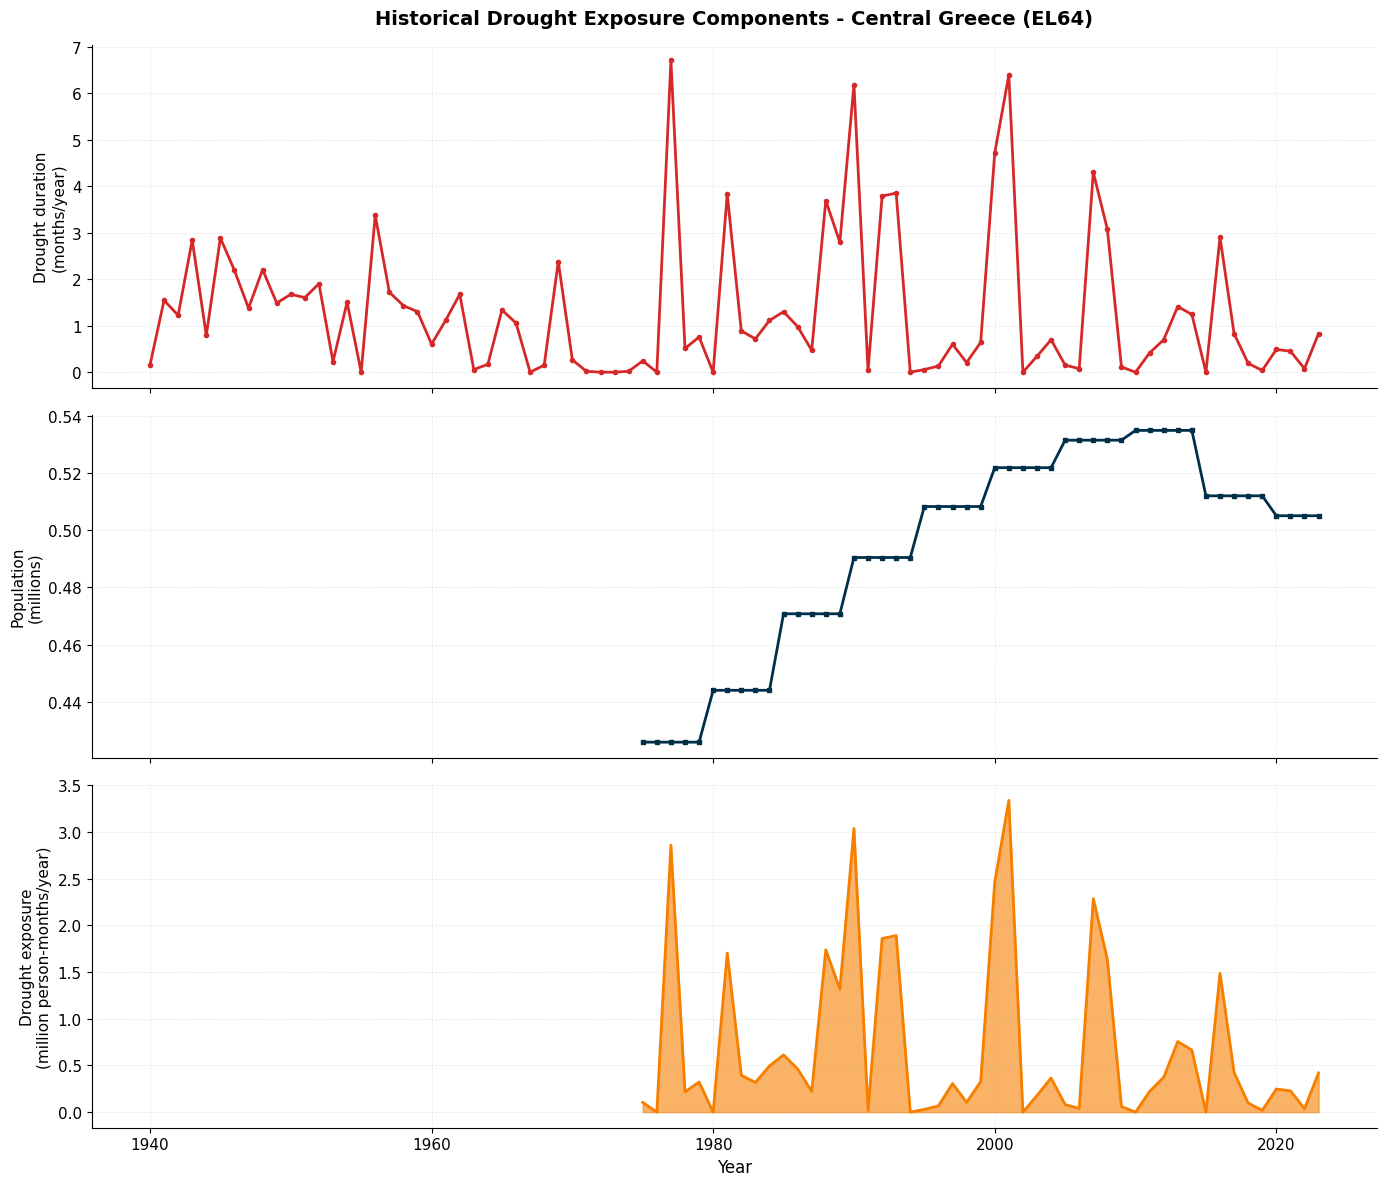


Historical baseline (1991-2020):
  Average drought duration: 1.25 months/year
  Average population: 0.52 million
  Average exposure: 0.64 million person-months/year


In [75]:
# Visualize historical exposure components
fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)

# Panel 1: Drought Duration
axes[0].plot(hist_exposure['year'], hist_exposure['dmd'], 
             color='#D62828', linewidth=2, marker='o', markersize=3)
axes[0].set_ylabel('Drought duration\n(months/year)', fontsize=11)
axes[0].set_title('Historical Drought Exposure Components - Central Greece (EL64)', 
                  fontsize=14, fontweight='bold', pad=15)
axes[0].grid(True, alpha=0.3, linestyle='--', linewidth=0.5)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# Panel 2: Population
axes[1].plot(hist_exposure['year'], hist_exposure['population']/1e6, 
             color='#003049', linewidth=2, marker='s', markersize=3)
axes[1].set_ylabel('Population\n(millions)', fontsize=11)
axes[1].grid(True, alpha=0.3, linestyle='--', linewidth=0.5)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

# Panel 3: Drought Exposure
axes[2].fill_between(hist_exposure['year'], 0, hist_exposure['exposure']/1e6,
                     color='#F77F00', alpha=0.6)
axes[2].plot(hist_exposure['year'], hist_exposure['exposure']/1e6, 
             color='#F77F00', linewidth=2)
axes[2].set_ylabel('Drought exposure\n(million person-months/year)', fontsize=11)
axes[2].set_xlabel('Year', fontsize=12)
axes[2].grid(True, alpha=0.3, linestyle='--', linewidth=0.5)
axes[2].spines['top'].set_visible(False)
axes[2].spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

# Calculate baseline statistics
baseline_hist = hist_exposure[
    hist_exposure['year'].between(baseline_start, baseline_end)
]

print(f"\nHistorical baseline ({baseline_start}-{baseline_end}):")
print(f"  Average drought duration: {baseline_hist['dmd'].mean():.2f} months/year")
print(f"  Average population: {baseline_hist['population'].mean()/1e6:.2f} million")
print(f"  Average exposure: {baseline_hist['exposure'].mean()/1e6:.2f} million person-months/year")

## Part 2: Future Drought Exposure Under Climate Change

Now we project future drought exposure by combining:
- **Climate model projections** of drought duration (multiple models × 2 RCP scenarios)
- **Population projections** from GHS-WUP (up to 2100)

We'll examine both RCP4.5 (moderate emissions) and RCP8.5 (high emissions) scenarios.

### RCP4.5 Scenario (Moderate Emissions)

In [94]:
# Prepare RCP4.5 projections
rcp45_df = drought_proj_df[drought_proj_df['scenario'] == 'RCP4_5'].copy()

# Merge with population for each model
rcp45_exposure = rcp45_df.merge(pop_df_filled, on='year', how='inner')
rcp45_exposure['exposure'] = rcp45_exposure['dmd'] * rcp45_exposure['population']

print(f"RCP4.5 projections: {rcp45_exposure['year'].min()}-{rcp45_exposure['year'].max()}")
print(f"Models: {rcp45_exposure['model'].nunique()}")

# Calculate multi-model statistics by year
rcp45_stats = rcp45_exposure.groupby('year').agg({
    'exposure': ['median', lambda x: np.percentile(x, 17), lambda x: np.percentile(x, 83)],
    'dmd' : ['median', lambda x: np.percentile(x, 17), lambda x: np.percentile(x, 83)]
}).reset_index()
rcp45_stats.columns = ['year', 'exposure_median', 'exposure_p17', 'exposure_p83', 'dmd_median', 'dmd_p17', 'dmd_p83']

rcp45_stats.head()

RCP4.5 projections: 1950-2100
Models: 9


,year,exposure_median,exposure_p17,exposure_p83,dmd_median,dmd_p17,dmd_p83
0,1950,NaN,NaN,NaN,1.321128,1.267696,3.491132
1,1951,NaN,NaN,NaN,0.942527,0.089135,2.464943
2,1952,NaN,NaN,NaN,1.009520,0.866911,2.104689
3,1953,NaN,NaN,NaN,1.568839,0.514251,3.397299
4,1954,NaN,NaN,NaN,0.652194,0.070744,2.045953


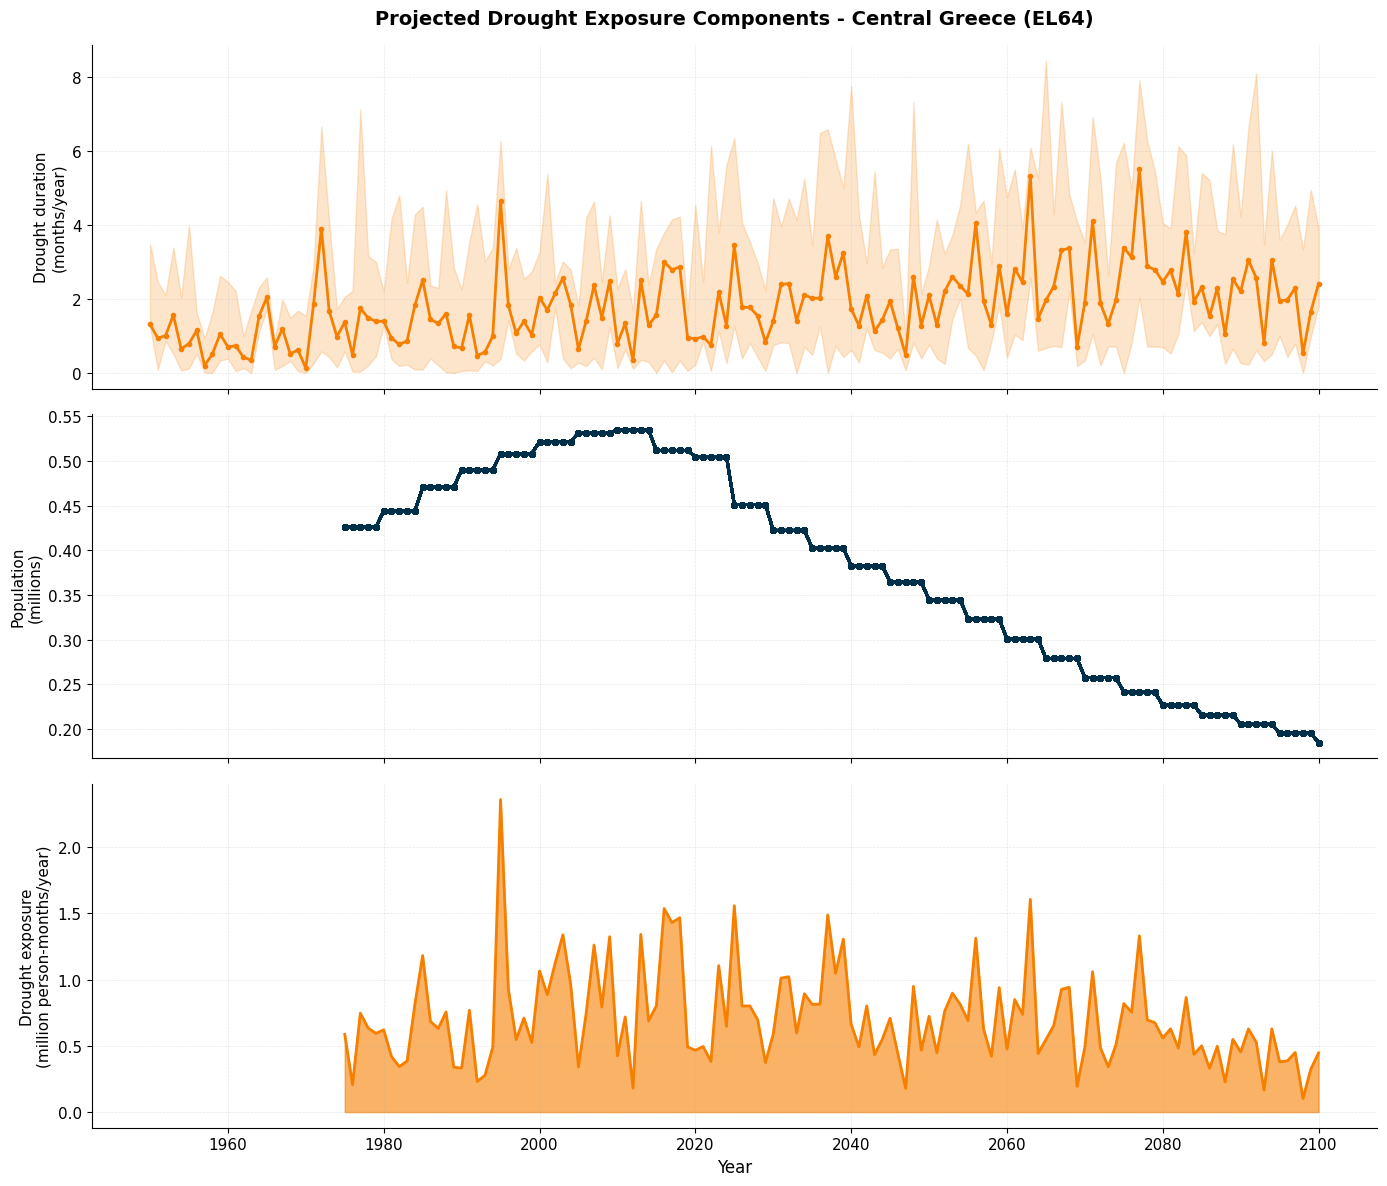

In [100]:
# Visualize projected exposure components
fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)

# Panel 1: Drought Duration
axes[0].plot(rcp45_stats['year'], rcp45_stats['dmd_median'], 
             color='#F77F00', linewidth=2, marker='o', markersize=3)
axes[0].set_ylabel('Drought duration\n(months/year)', fontsize=11)
axes[0].set_title('Projected Drought Exposure Components - Central Greece (EL64)', 
                  fontsize=14, fontweight='bold', pad=15)
axes[0].grid(True, alpha=0.3, linestyle='--', linewidth=0.5)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)
# Add uncertainty range
axes[0].fill_between(rcp45_stats['year'], 
                rcp45_stats['dmd_p17'],
                rcp45_stats['dmd_p83'],
                color='#F77F00', alpha=0.2, label='RCP4.5 (17th-83rd percentile)')

# Panel 2: Population
axes[1].plot(rcp45_exposure['year'], rcp45_exposure['population']/1e6, 
             color='#003049', linewidth=2, marker='s', markersize=3)
axes[1].set_ylabel('Population\n(millions)', fontsize=11)
axes[1].grid(True, alpha=0.3, linestyle='--', linewidth=0.5)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

# Panel 3: Drought Exposure
axes[2].fill_between(rcp45_stats['year'], 0, rcp45_stats['exposure_median']/1e6,
                     color='#F77F00', alpha=0.6)
axes[2].plot(rcp45_stats['year'], rcp45_stats['exposure_median']/1e6, 
             color='#F77F00', linewidth=2)
axes[2].set_ylabel('Drought exposure\n(million person-months/year)', fontsize=11)
axes[2].set_xlabel('Year', fontsize=12)
axes[2].grid(True, alpha=0.3, linestyle='--', linewidth=0.5)
axes[2].spines['top'].set_visible(False)
axes[2].spines['right'].set_visible(False)

plt.tight_layout()
plt.show()



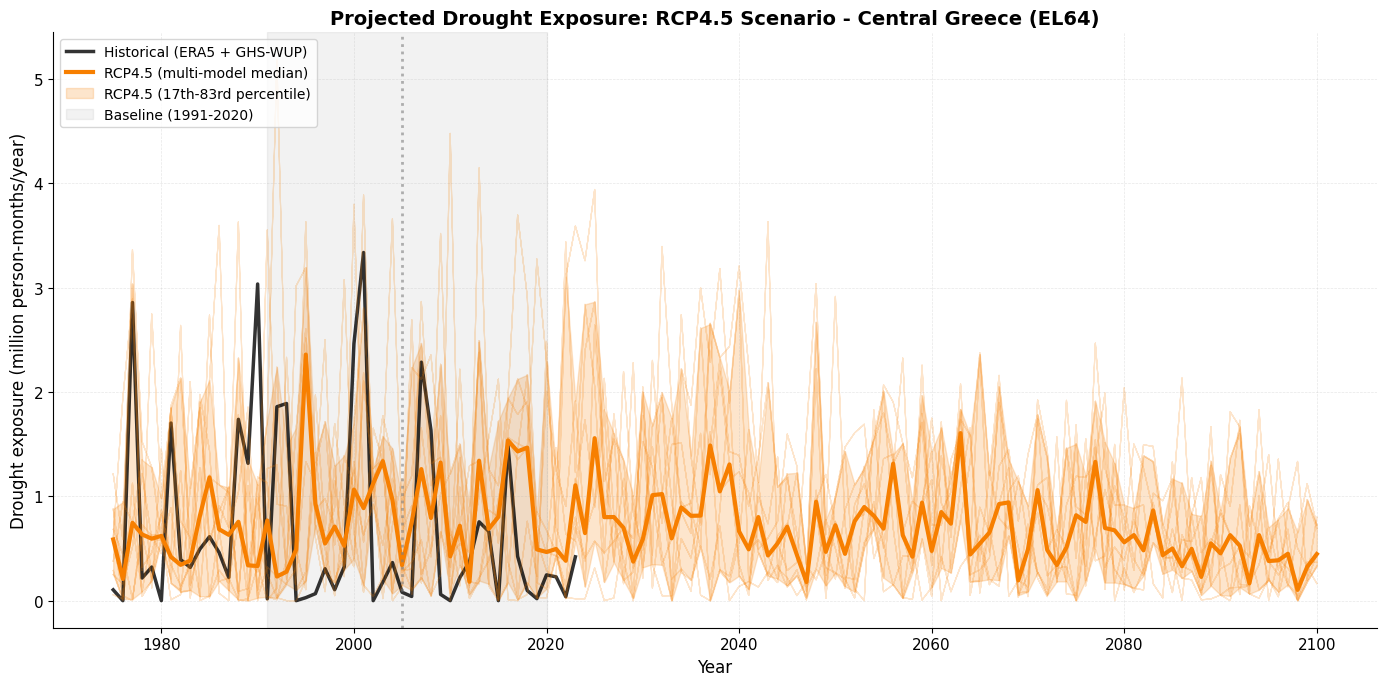

In [77]:
# Visualize RCP4.5 projections
fig, ax = plt.subplots(figsize=(14, 7))

# Plot historical exposure
ax.plot(hist_exposure['year'], hist_exposure['exposure']/1e6,
        color='black', linewidth=2.5, label='Historical (ERA5 + GHS-WUP)', alpha=0.8)

# Plot individual models (light)
for model in rcp45_exposure['model'].unique():
    model_data = rcp45_exposure[rcp45_exposure['model'] == model]
    ax.plot(model_data['year'], model_data['exposure']/1e6,
            color='#F77F00', linewidth=0.8, alpha=0.2)

# Plot multi-model median
ax.plot(rcp45_stats['year'], rcp45_stats['exposure_median']/1e6,
        color='#F77F00', linewidth=3, label='RCP4.5 (multi-model median)')

# Add uncertainty range
ax.fill_between(rcp45_stats['year'], 
                rcp45_stats['exposure_p17']/1e6,
                rcp45_stats['exposure_p83']/1e6,
                color='#F77F00', alpha=0.2, label='RCP4.5 (17th-83rd percentile)')

# Mark transition from historical to projections
ax.axvline(2005, color='gray', linestyle=':', linewidth=2, alpha=0.6)

# Mark baseline period
ax.axvspan(baseline_start, baseline_end, color='gray', alpha=0.1, label=f'Baseline ({baseline_start}-{baseline_end})')

ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Drought exposure (million person-months/year)', fontsize=12)
ax.set_title('Projected Drought Exposure: RCP4.5 Scenario - Central Greece (EL64)', 
             fontsize=14, fontweight='bold')
ax.legend(loc='upper left', fontsize=10, frameon=True)
ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

### RCP8.5 Scenario (High Emissions)

In [103]:
# Prepare RCP8.5 projections
rcp85_df = drought_proj_df[drought_proj_df['scenario'] == 'RCP8_5'].copy()

# Merge with population
rcp85_exposure = rcp85_df.merge(pop_df_filled, on='year', how='inner')
rcp85_exposure['exposure'] = rcp85_exposure['dmd'] * rcp85_exposure['population']

# Calculate multi-model statistics
rcp85_stats = rcp85_exposure.groupby('year').agg({
    'exposure': ['median', lambda x: np.percentile(x, 17), lambda x: np.percentile(x, 83)],
        'dmd' : ['median', lambda x: np.percentile(x, 17), lambda x: np.percentile(x, 83)]
}).reset_index()
rcp85_stats.columns = ['year', 'exposure_median', 'exposure_p17', 'exposure_p83', 'dmd_median', 'dmd_p17', 'dmd_p83']

print(f"RCP8.5 projections: {rcp85_exposure['year'].min()}-{rcp85_exposure['year'].max()}")
print(f"Models: {rcp85_exposure['model'].nunique()}")

RCP8.5 projections: 1950-2100
Models: 9


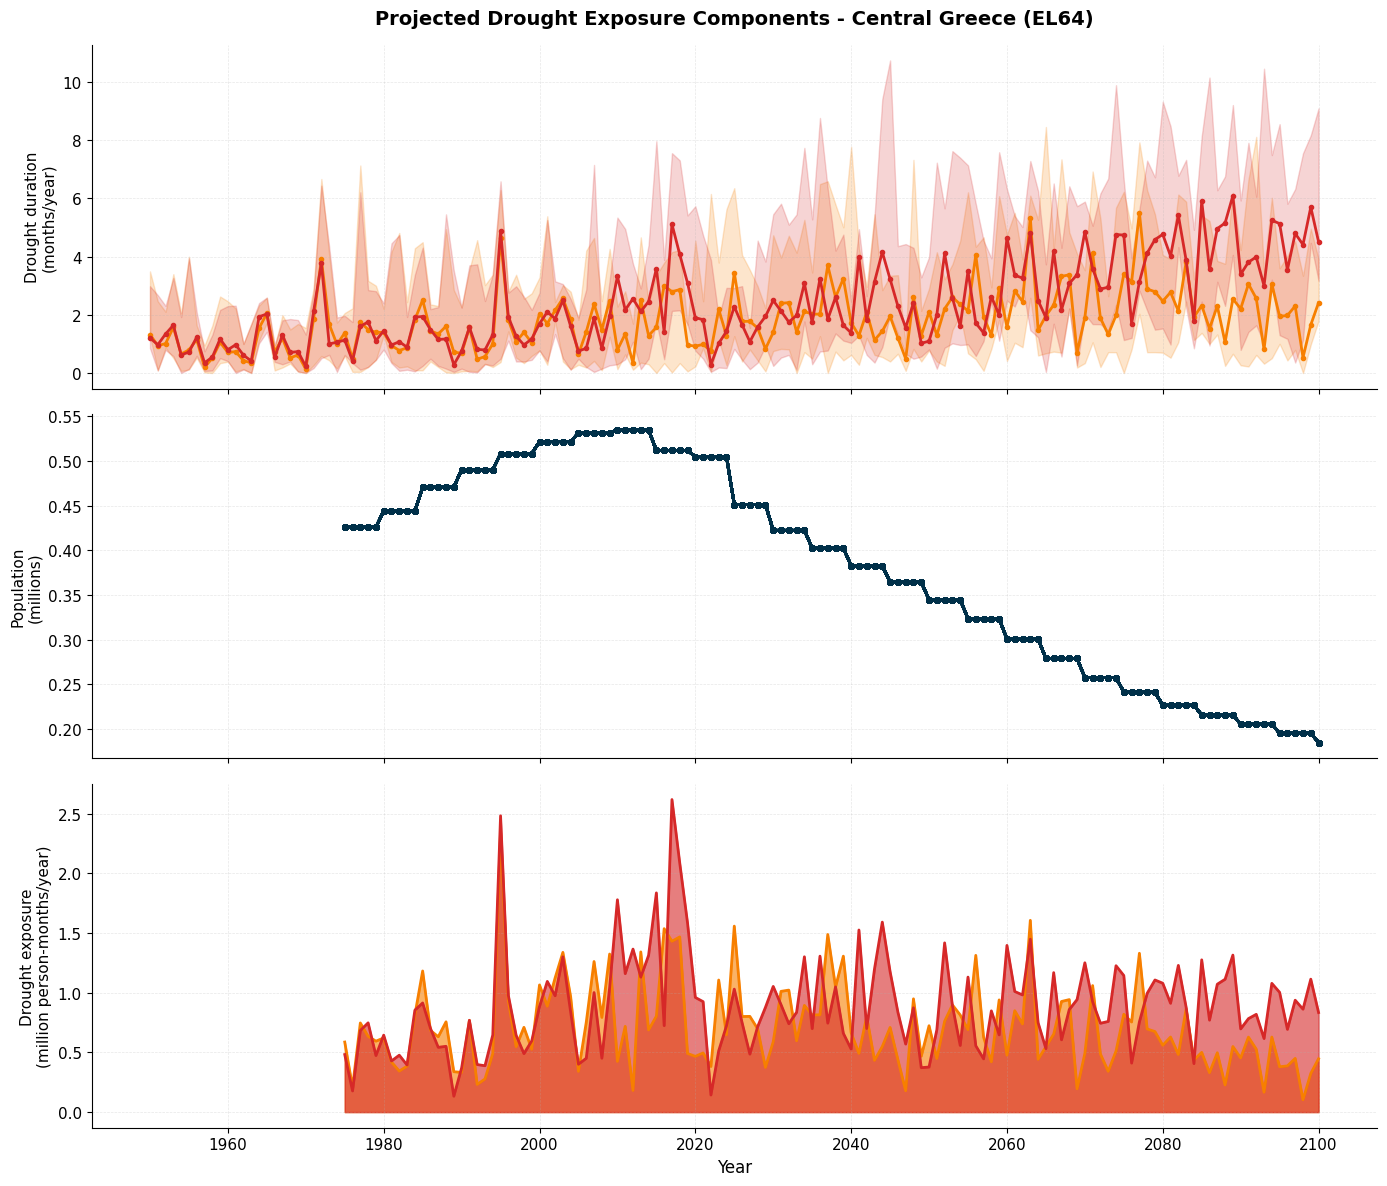

In [105]:
# Visualize projected exposure components
fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)

# Panel 1: Drought Duration
axes[0].plot(rcp45_stats['year'], rcp45_stats['dmd_median'], 
             color='#F77F00', linewidth=2, marker='o', markersize=3)
axes[0].plot(rcp85_stats['year'], rcp85_stats['dmd_median'], 
             color='#D62828', linewidth=2, marker='o', markersize=3)
axes[0].set_ylabel('Drought duration\n(months/year)', fontsize=11)
axes[0].set_title('Projected Drought Exposure Components - Central Greece (EL64)', 
                  fontsize=14, fontweight='bold', pad=15)
axes[0].grid(True, alpha=0.3, linestyle='--', linewidth=0.5)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)
# Add uncertainty range
axes[0].fill_between(rcp45_stats['year'], 
                rcp45_stats['dmd_p17'],
                rcp45_stats['dmd_p83'],
                color='#F77F00', alpha=0.2, label='RCP4.5 (17th-83rd percentile)')
axes[0].fill_between(rcp85_stats['year'], 
                rcp85_stats['dmd_p17'],
                rcp85_stats['dmd_p83'],
                color='#D62828', alpha=0.2, label='RCP8.5 (17th-83rd percentile)')

# Panel 2: Population
axes[1].plot(rcp45_exposure['year'], rcp45_exposure['population']/1e6, 
             color='#003049', linewidth=2, marker='s', markersize=3)
axes[1].set_ylabel('Population\n(millions)', fontsize=11)
axes[1].grid(True, alpha=0.3, linestyle='--', linewidth=0.5)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

# Panel 3: Drought Exposure
axes[2].fill_between(rcp45_stats['year'], 0, rcp45_stats['exposure_median']/1e6,
                     color='#F77F00', alpha=0.6)
axes[2].fill_between(rcp85_stats['year'], 0, rcp85_stats['exposure_median']/1e6,
                     color='#D62828', alpha=0.6)
axes[2].plot(rcp45_stats['year'], rcp45_stats['exposure_median']/1e6, 
             color='#F77F00', linewidth=2)
axes[2].plot(rcp85_stats['year'], rcp85_stats['exposure_median']/1e6, 
             color='#D62828', linewidth=2)
axes[2].set_ylabel('Drought exposure\n(million person-months/year)', fontsize=11)
axes[2].set_xlabel('Year', fontsize=12)
axes[2].grid(True, alpha=0.3, linestyle='--', linewidth=0.5)
axes[2].spines['top'].set_visible(False)
axes[2].spines['right'].set_visible(False)

plt.tight_layout()
plt.show()



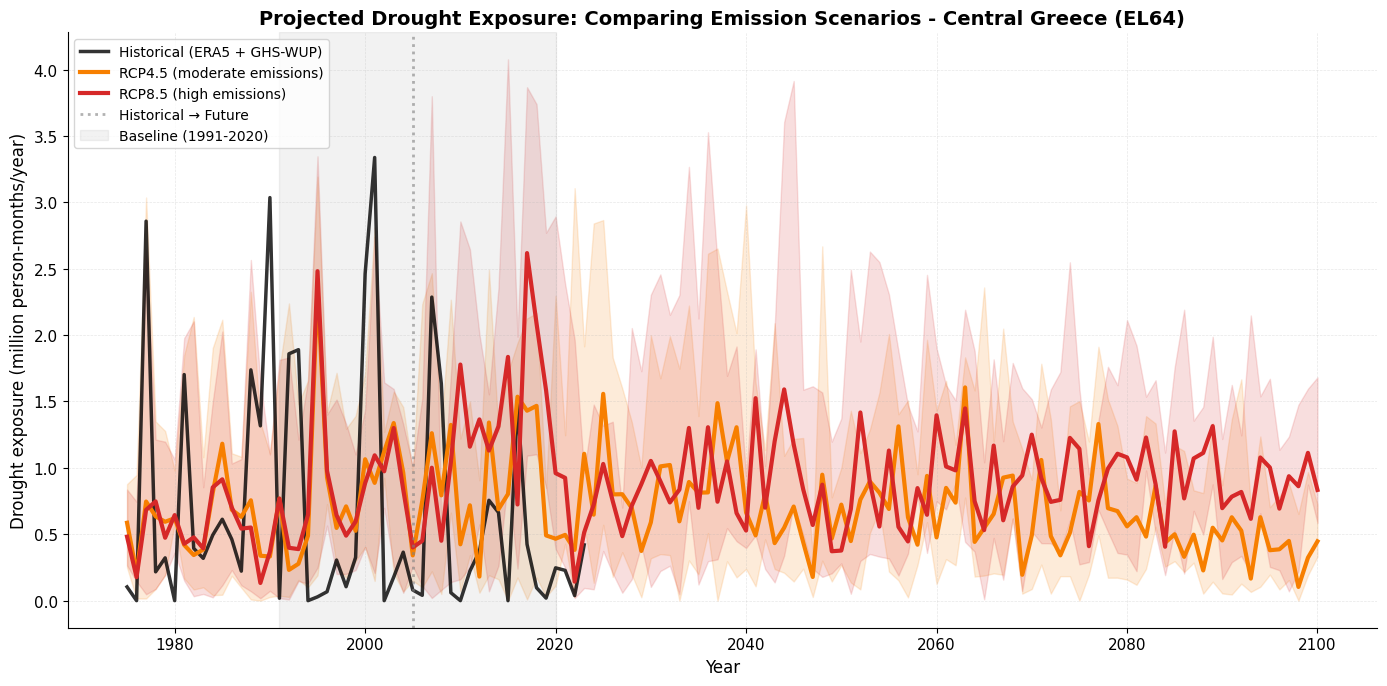

In [79]:
# Compare RCP4.5 vs RCP8.5
fig, ax = plt.subplots(figsize=(14, 7))

# Historical
ax.plot(hist_exposure['year'], hist_exposure['exposure']/1e6,
        color='black', linewidth=2.5, label='Historical (ERA5 + GHS-WUP)', alpha=0.8)

# RCP4.5
ax.plot(rcp45_stats['year'], rcp45_stats['exposure_median']/1e6,
        color='#F77F00', linewidth=3, label='RCP4.5 (moderate emissions)')
ax.fill_between(rcp45_stats['year'], 
                rcp45_stats['exposure_p17']/1e6,
                rcp45_stats['exposure_p83']/1e6,
                color='#F77F00', alpha=0.15)

# RCP8.5
ax.plot(rcp85_stats['year'], rcp85_stats['exposure_median']/1e6,
        color='#D62828', linewidth=3, label='RCP8.5 (high emissions)')
ax.fill_between(rcp85_stats['year'], 
                rcp85_stats['exposure_p17']/1e6,
                rcp85_stats['exposure_p83']/1e6,
                color='#D62828', alpha=0.15)

# Mark transitions and baseline
ax.axvline(2005, color='gray', linestyle=':', linewidth=2, alpha=0.6, label='Historical → Future')
ax.axvspan(baseline_start, baseline_end, color='gray', alpha=0.1, label=f'Baseline ({baseline_start}-{baseline_end})')

ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Drought exposure (million person-months/year)', fontsize=12)
ax.set_title('Projected Drought Exposure: Comparing Emission Scenarios - Central Greece (EL64)', 
             fontsize=14, fontweight='bold')
ax.legend(loc='upper left', fontsize=10, frameon=True)
ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

In [108]:
# Prepare RCP8.5 projections
rcp45_df_rm = drought_proj_df[drought_proj_df['scenario'] == 'RCP4_5'].copy()

# Calculate rolling mean for drought duration (3-year window) to smooth projections
window=30
rcp45_df_rm['dmd'] = rcp45_df_rm.groupby('model')['dmd'].transform(lambda x: x.rolling(window=window, center=True, min_periods=1).mean())

# Merge with population
rcp45_exposure_rm = rcp45_df_rm.merge(pop_df_filled, on='year', how='inner')
rcp45_exposure_rm['exposure'] = rcp45_exposure_rm['dmd'] * rcp45_exposure_rm['population']

# Calculate multi-model statistics
rcp45_stats_rm = rcp45_exposure_rm.groupby('year').agg({
    'exposure': ['median', lambda x: np.percentile(x, 17), lambda x: np.percentile(x, 83)],
        'dmd' : ['median', lambda x: np.percentile(x, 17), lambda x: np.percentile(x, 83)]
}).reset_index()
rcp45_stats_rm.columns = ['year', 'exposure_median', 'exposure_p17', 'exposure_p83', 'dmd_median', 'dmd_p17', 'dmd_p83']

print(f"RCP4.5 projections: {rcp45_exposure_rm['year'].min()}-{rcp45_exposure_rm['year'].max()}")
print(f"Models: {rcp45_exposure_rm['model'].nunique()}")


# Prepare RCP8.5 projections
rcp85_df_rm = drought_proj_df[drought_proj_df['scenario'] == 'RCP8_5'].copy()

# Calculate rolling mean for drought duration (3-year window) to smooth projections
window=30
rcp85_df_rm['dmd'] = rcp85_df_rm.groupby('model')['dmd'].transform(lambda x: x.rolling(window=window, center=True, min_periods=1).mean())

# Merge with population
rcp85_exposure_rm = rcp85_df_rm.merge(pop_df_filled, on='year', how='inner')
rcp85_exposure_rm['exposure'] = rcp85_exposure_rm['dmd'] * rcp85_exposure_rm['population']

# Calculate multi-model statistics
rcp85_stats_rm = rcp85_exposure_rm.groupby('year').agg({
    'exposure': ['median', lambda x: np.percentile(x, 17), lambda x: np.percentile(x, 83)],
        'dmd' : ['median', lambda x: np.percentile(x, 17), lambda x: np.percentile(x, 83)]
}).reset_index()
rcp85_stats_rm.columns = ['year', 'exposure_median', 'exposure_p17', 'exposure_p83', 'dmd_median', 'dmd_p17', 'dmd_p83']

print(f"RCP8.5 projections: {rcp85_exposure_rm['year'].min()}-{rcp85_exposure_rm['year'].max()}")
print(f"Models: {rcp85_exposure_rm['model'].nunique()}")

RCP4.5 projections: 1950-2100
Models: 9
RCP8.5 projections: 1950-2100
Models: 9


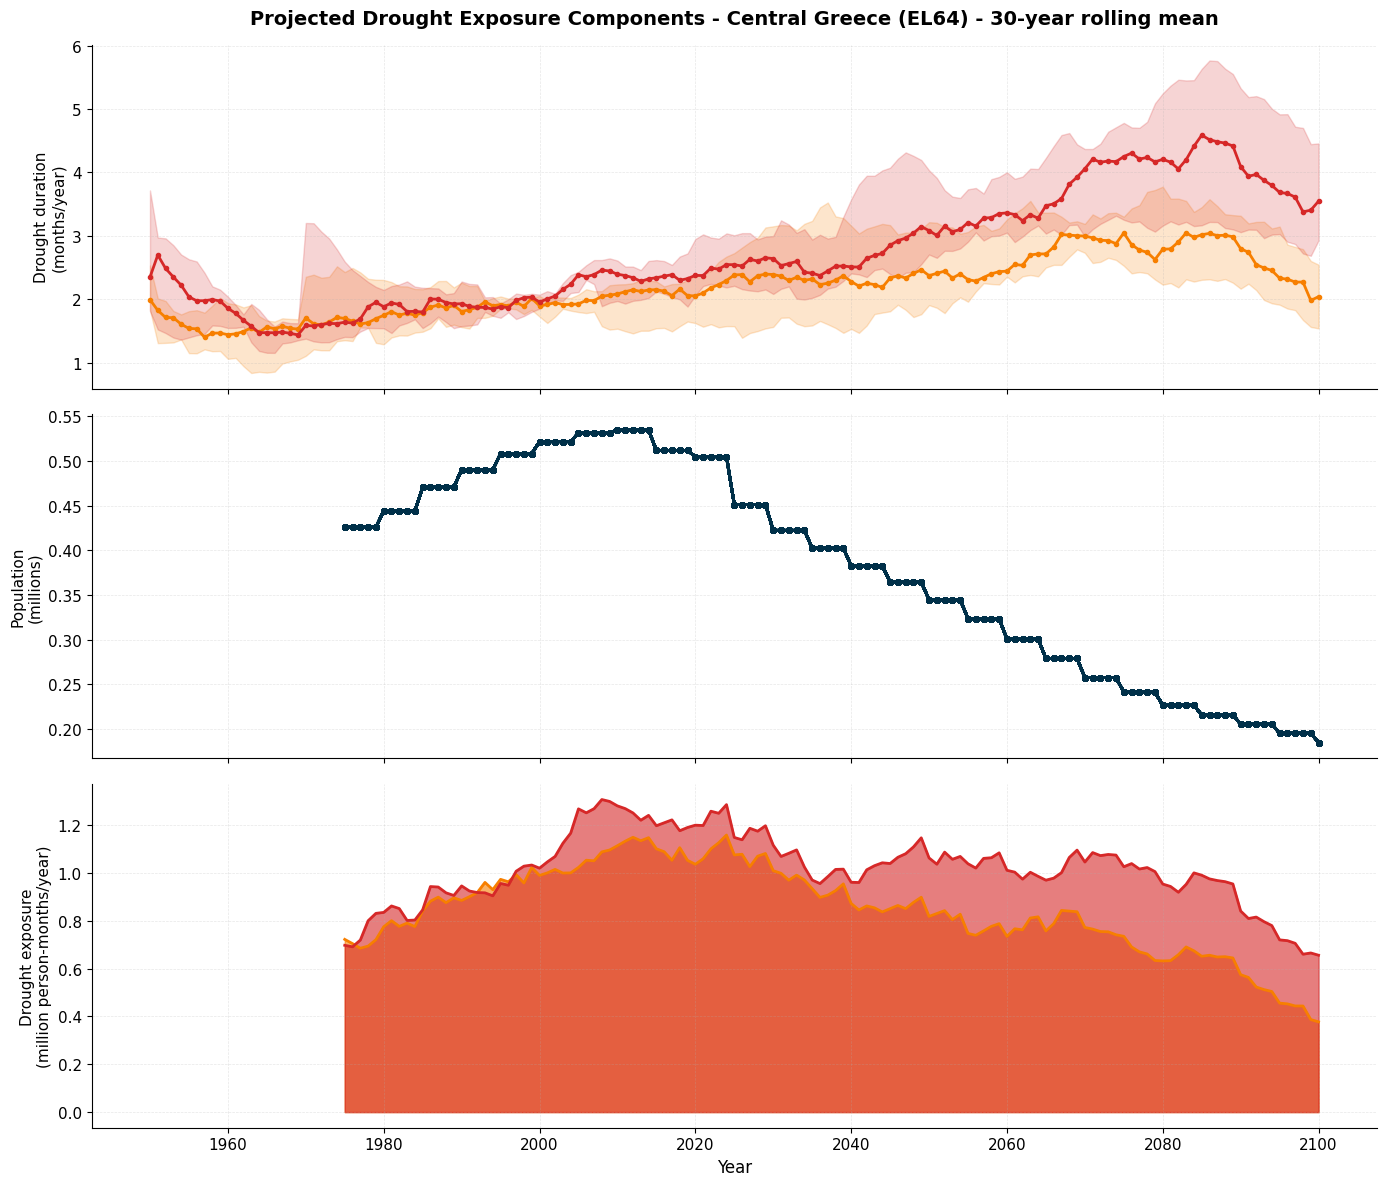

In [ ]:
# Visualize projected exposure components
fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)

# Panel 1: Drought Duration
axes[0].plot(rcp45_stats_rm['year'], rcp45_stats_rm['dmd_median'], 
             color='#F77F00', linewidth=2, marker='o', markersize=3)
axes[0].plot(rcp85_stats_rm['year'], rcp85_stats_rm['dmd_median'], 
             color='#D62828', linewidth=2, marker='o', markersize=3)
axes[0].set_ylabel('Drought duration\n(months/year)', fontsize=11)
axes[0].set_title('Projected Drought Exposure Components - Central Greece (EL64) - 30-year rolling mean', 
                  fontsize=14, fontweight='bold', pad=15)
axes[0].grid(True, alpha=0.3, linestyle='--', linewidth=0.5)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)
# Add uncertainty range
axes[0].fill_between(rcp45_stats['year'], 
                rcp45_stats_rm['dmd_p17'],
                rcp45_stats_rm['dmd_p83'],
                color='#F77F00', alpha=0.2, label='RCP4.5 (17th-83rd percentile)')
axes[0].fill_between(rcp85_stats['year'], 
                rcp85_stats_rm['dmd_p17'],
                rcp85_stats_rm['dmd_p83'],
                color='#D62828', alpha=0.2, label='RCP8.5 (17th-83rd percentile)')

# Panel 2: Population
axes[1].plot(rcp45_exposure_rm['year'], rcp45_exposure_rm['population']/1e6, 
             color='#003049', linewidth=2, marker='s', markersize=3)
axes[1].set_ylabel('Population\n(millions)', fontsize=11)
axes[1].grid(True, alpha=0.3, linestyle='--', linewidth=0.5)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

# Panel 3: Drought Exposure
axes[2].fill_between(rcp45_stats_rm['year'], 0, rcp45_stats_rm['exposure_median']/1e6,
                     color='#F77F00', alpha=0.6)
axes[2].fill_between(rcp85_stats_rm['year'], 0, rcp85_stats_rm['exposure_median']/1e6,
                     color='#D62828', alpha=0.6)
axes[2].plot(rcp45_stats_rm['year'], rcp45_stats_rm['exposure_median']/1e6, 
             color='#F77F00', linewidth=2)
axes[2].plot(rcp85_stats_rm['year'], rcp85_stats_rm['exposure_median']/1e6, 
             color='#D62828', linewidth=2)
axes[2].set_ylabel('Drought exposure\n(million person-months/year)', fontsize=11)
axes[2].set_xlabel('Year', fontsize=12)
axes[2].grid(True, alpha=0.3, linestyle='--', linewidth=0.5)
axes[2].spines['top'].set_visible(False)
axes[2].spines['right'].set_visible(False)

plt.tight_layout()
plt.show()



2.0011656777028186
2.1831219914551876
516921.6624755524
1035118.126941163
1130665.100971916


<Axes: xlabel='year'>

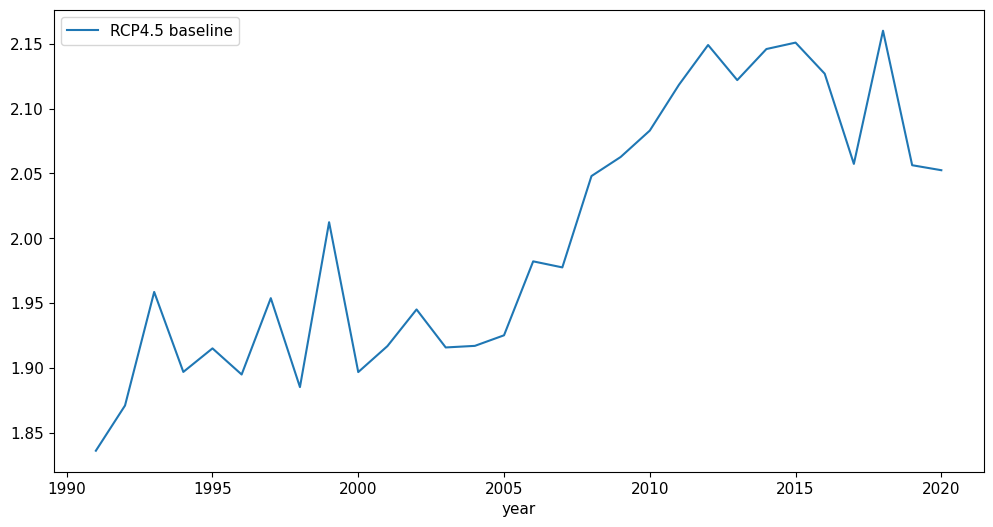

In [121]:
# Calculate anomalies relative to baseline of RCPs  
baseline_rcp45 = rcp45_stats_rm[rcp45_stats_rm['year'].between(baseline_start, baseline_end)]
baseline_rcp85 = rcp85_stats_rm[rcp85_stats_rm['year'].between(baseline_start, baseline_end)]
baseline_rcp45_dmd = baseline_rcp45['dmd_median'].mean()
baseline_rcp85_dmd = baseline_rcp85['dmd_median'].mean()
baseline_population = pop_df_filled[pop_df_filled['year'].between(baseline_start, baseline_end)]['population'].mean()
baseline_rcp45_exposure = baseline_rcp45['exposure_median'].mean() 
baseline_rcp85_exposure = baseline_rcp85['exposure_median'].mean()


print(baseline_rcp45_dmd)
print(baseline_rcp85_dmd)
print(baseline_population)
print(baseline_rcp45_exposure)
print(baseline_rcp85_exposure)

baseline_rcp45.plot(x='year', y='dmd_median', label='RCP4.5 baseline')

## End-of-Century Projections (2071-2100)

Let's quantify the projected changes in drought exposure by the end of the century, accounting for model uncertainty.

In [80]:
# Calculate baseline exposure (1991-2020) from climate models
baseline_models = drought_proj_df[
    drought_proj_df['year'].between(baseline_start, baseline_end)
].groupby(['model', 'scenario'])[['year', 'dmd']].median().reset_index()

baseline_pop = pop_df[
    pop_df['year'].between(baseline_start, baseline_end)
]['population'].median()

baseline_models['exposure'] = baseline_models['dmd'] * baseline_pop

# Calculate end-of-century exposure (2071-2100)
eoc_models = drought_proj_df[
    drought_proj_df['year'].between(2071, 2100)
].groupby(['model', 'scenario'])[['year', 'dmd']].median().reset_index()

eoc_pop = pop_df[
    pop_df['year'].between(2071, 2100)
]['population'].median()

eoc_models['exposure'] = eoc_models['dmd'] * eoc_pop

# Merge and calculate changes
changes = eoc_models.merge(baseline_models, on=['model', 'scenario'], suffixes=('_eoc', '_baseline'))
changes['exposure_change'] = changes['exposure_eoc'] - changes['exposure_baseline']
changes['exposure_change_pct'] = (changes['exposure_change'] / changes['exposure_baseline']) * 100

# Summarize by scenario
print("="*80)
print(f"DROUGHT EXPOSURE PROJECTIONS: END-OF-CENTURY (2071-2100)")
print(f"Baseline period: {baseline_start}-{baseline_end}")
print("="*80)

print(f"\nBaseline ({baseline_start}-{baseline_end}):")
print(f"  Population: {baseline_pop/1e6:.2f} million")
baseline_exp = baseline_models.groupby('scenario')['exposure'].median().mean()
print(f"  Drought exposure: {baseline_exp/1e6:.2f} million person-months/year")

print(f"\nEnd-of-century (2071-2100):")
print(f"  Projected population: {eoc_pop/1e6:.2f} million")

for scenario in ['RCP4_5', 'RCP8_5']:
    scenario_changes = changes[changes['scenario'] == scenario]
    
    exp_median = scenario_changes['exposure_eoc'].median()
    exp_p17 = scenario_changes['exposure_eoc'].quantile(0.17)
    exp_p83 = scenario_changes['exposure_eoc'].quantile(0.83)
    
    change_median = scenario_changes['exposure_change'].median()
    change_pct_median = scenario_changes['exposure_change_pct'].median()
    
    n_increase = (scenario_changes['exposure_change'] > 0).sum()
    n_total = len(scenario_changes)
    
    print(f"\n  {scenario.replace('_', '.')}:")
    print(f"    Median exposure: {exp_median/1e6:.2f} million person-months/year")
    print(f"    Uncertainty range: {exp_p17/1e6:.2f} - {exp_p83/1e6:.2f} million person-months/year")
    print(f"    Change from baseline: {change_median/1e6:+.2f} million person-months/year ({change_pct_median:+.1f}%)")
    print(f"    Model agreement: {n_increase}/{n_total} models show increase")

print("\n" + "="*80)

DROUGHT EXPOSURE PROJECTIONS: END-OF-CENTURY (2071-2100)
Baseline period: 1991-2020

Baseline (1991-2020):
  Population: 0.52 million
  Drought exposure: 0.89 million person-months/year

End-of-century (2071-2100):
  Projected population: 0.22 million

  RCP4.5:
    Median exposure: 0.54 million person-months/year
    Uncertainty range: 0.32 - 0.72 million person-months/year
    Change from baseline: -0.33 million person-months/year (-35.2%)
    Model agreement: 2/9 models show increase

  RCP8.5:
    Median exposure: 0.98 million person-months/year
    Uncertainty range: 0.73 - 1.12 million person-months/year
    Change from baseline: -0.15 million person-months/year (-13.8%)
    Model agreement: 4/9 models show increase



/etc/ecmwf/ssd/ssd1/jupyterhub/nejk-jupyterhub/tmpdirs/nejk.49552510/ipykernel_1287033/1979033715.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=labels, patch_artist=True,


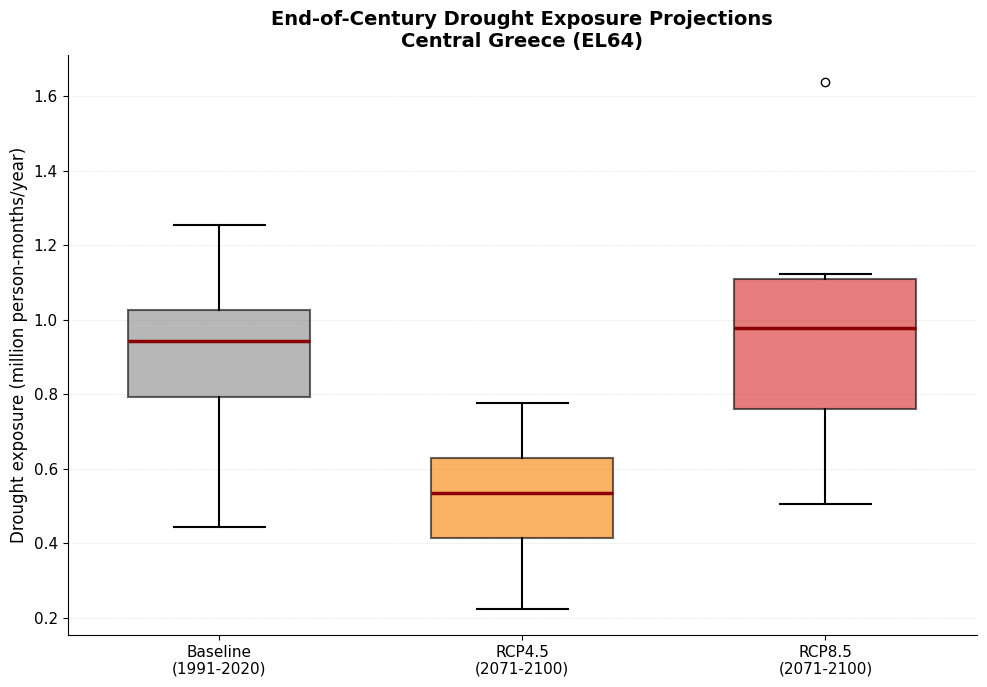


💡 Key Insight: The boxplot shows the median (red line), interquartile range (box),
   and full range of model projections (whiskers). This visualizes model uncertainty.


In [81]:
# Visualize end-of-century projections with uncertainty
fig, ax = plt.subplots(figsize=(10, 7))

# Prepare data for boxplot
data_to_plot = [
    baseline_models['exposure'].values / 1e6,
    changes[changes['scenario'] == 'RCP4_5']['exposure_eoc'].values / 1e6,
    changes[changes['scenario'] == 'RCP8_5']['exposure_eoc'].values / 1e6
]

labels = [f'Baseline\n({baseline_start}-{baseline_end})', 
          f'RCP4.5\n(2071-2100)', 
          f'RCP8.5\n(2071-2100)']

bp = ax.boxplot(data_to_plot, labels=labels, patch_artist=True,
                widths=0.6, showfliers=True,
                boxprops=dict(linewidth=1.5),
                medianprops=dict(color='darkred', linewidth=2.5),
                whiskerprops=dict(linewidth=1.5),
                capprops=dict(linewidth=1.5))

# Color boxes
colors = ['#888888', '#F77F00', '#D62828']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)

ax.set_ylabel('Drought exposure (million person-months/year)', fontsize=12)
ax.set_title('End-of-Century Drought Exposure Projections\nCentral Greece (EL64)', 
             fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.5, axis='y')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

print("\n💡 Key Insight: The boxplot shows the median (red line), interquartile range (box),")
print("   and full range of model projections (whiskers). This visualizes model uncertainty.")

## Threshold-Based Exposure Analysis

Instead of looking at total drought exposure, we can examine **how many people are exposed to significant drought increases over 30-year periods**. This approach:

- Calculates **cumulative drought months** for each 30-year period (baseline: 1991-2020, future: 2021-2050, 2041-2070, 2071-2100)
- Compares future periods to the baseline to identify **drought increases**
- Evaluates population exposed when increases exceed specific thresholds
- Accounts for **model uncertainty** by showing the range of projections

This helps answer questions like: "How many people will experience at least 10 additional months of drought per 30-year period compared to the 1991-2020 baseline?"

In [82]:
# Configuration: Define 30-year periods and thresholds
period_length = 30  # years per period
thresholds = [10, 15, 20]  # additional drought months per 30-year period

# Define analysis periods
periods = {
    'Baseline': (1991, 2020),
    'Near-term': (2021, 2050),
    'Mid-term': (2041, 2070),
    'Long-term': (2071, 2100)
}

print(f"Configuration:")
print(f"  Period length: {period_length} years")
print(f"  Thresholds: {thresholds} additional drought months per {period_length}-year period")
print(f"\nAnalysis periods:")
for name, (start, end) in periods.items():
    print(f"  {name}: {start}-{end}")

Configuration:
  Period length: 30 years
  Thresholds: [10, 15, 20] additional drought months per 30-year period

Analysis periods:
  Baseline: 1991-2020
  Near-term: 2021-2050
  Mid-term: 2041-2070
  Long-term: 2071-2100


In [83]:
# Calculate cumulative drought months for each 30-year period
def calculate_period_drought_exposure(drought_df, pop_df, periods, thresholds):
    """Calculate population exposed to drought increases per 30-year period.
    
    Parameters:
    -----------
    drought_df : DataFrame
        Drought projection data
    pop_df : DataFrame
        Population data
    periods : dict
        Dictionary of period names and (start, end) year tuples
    thresholds : list
        List of threshold values for drought month increases
    
    Returns:
    --------
    dict : Results for each threshold containing exposure statistics by period and scenario
    """
    
    # Calculate baseline (1991-2020) cumulative drought for each model
    # Note: Take mean across scenarios for historical period (should be identical)
    baseline_start, baseline_end = periods['Baseline']
    baseline_df = drought_df[
        drought_df['year'].between(baseline_start, baseline_end)
    ].groupby(['model', 'scenario']).agg({
        'dmd': 'sum'  # Total drought months over 30 years
    }).reset_index()
    # Average across scenarios (historical period should be same for both RCPs)
    baseline_df = baseline_df.groupby('model')['dmd'].mean().reset_index()
    baseline_df.rename(columns={'dmd': 'baseline_total'}, inplace=True)
    
    print(f"Baseline cumulative drought ({baseline_start}-{baseline_end}):")
    print(f"  Mean across models: {baseline_df['baseline_total'].mean():.1f} months per {period_length} years")
    print(f"  Range: {baseline_df['baseline_total'].min():.1f} - {baseline_df['baseline_total'].max():.1f} months")
    print(f"  Average per year: {baseline_df['baseline_total'].mean()/period_length:.2f} months/year")
    
    # Calculate cumulative drought for each future period
    results = {threshold: [] for threshold in thresholds}
    
    for period_name, (start, end) in periods.items():
        if period_name == 'Baseline':
            continue
            
        # Calculate total drought months for this period
        period_df = drought_df[
            drought_df['year'].between(start, end)
        ].groupby(['model', 'scenario']).agg({
            'dmd': 'sum'
        }).reset_index()
        period_df.rename(columns={'dmd': 'period_total'}, inplace=True)
        
        # Merge with baseline (baseline is same for all scenarios)
        merged = period_df.merge(baseline_df[['model', 'baseline_total']], 
                                 on='model')
        merged['drought_increase'] = merged['period_total'] - merged['baseline_total']
        
        # Get population for this period (median across years)
        period_pop = pop_df[pop_df['year'].between(start, end)]['population'].median()
        
        # For each threshold, calculate exposure
        for threshold in thresholds:
            # Models where drought increase exceeds threshold
            for scenario in merged['scenario'].unique():
                scenario_data = merged[merged['scenario'] == scenario]
                
                # Count how many models exceed threshold
                exceeds = scenario_data['drought_increase'] >= threshold
                
                # Population exposed (if any model shows exceedance, all population is at risk)
                # We'll calculate the fraction of models that show exceedance
                exposed_models = exceeds.sum()
                total_models = len(scenario_data)
                
                # Store results
                results[threshold].append({
                    'period': period_name,
                    'scenario': scenario,
                    'period_years': f'{start}-{end}',
                    'population': period_pop,
                    'exposed_median': period_pop if exposed_models > total_models/2 else 0,
                    'exposed_min': 0 if exposed_models == 0 else period_pop,
                    'exposed_max': period_pop if exposed_models > 0 else 0,
                    'n_models_exceed': exposed_models,
                    'n_models_total': total_models,
                    'drought_increase_median': scenario_data['drought_increase'].median(),
                    'drought_increase_p17': scenario_data['drought_increase'].quantile(0.17),
                    'drought_increase_p83': scenario_data['drought_increase'].quantile(0.83)
                })
    
    # Convert to DataFrames
    for threshold in thresholds:
        results[threshold] = pd.DataFrame(results[threshold])
    
    return results

# Calculate exposure for all thresholds
threshold_results = calculate_period_drought_exposure(
    drought_proj_df, pop_df, periods, thresholds
)

print(f"\n✓ Threshold-based exposure calculated for {len(thresholds)} thresholds")

Baseline cumulative drought (1991-2020):
  Mean across models: 260.4 months per 30 years
  Range: 213.4 - 307.5 months
  Average per year: 8.68 months/year

✓ Threshold-based exposure calculated for 3 thresholds


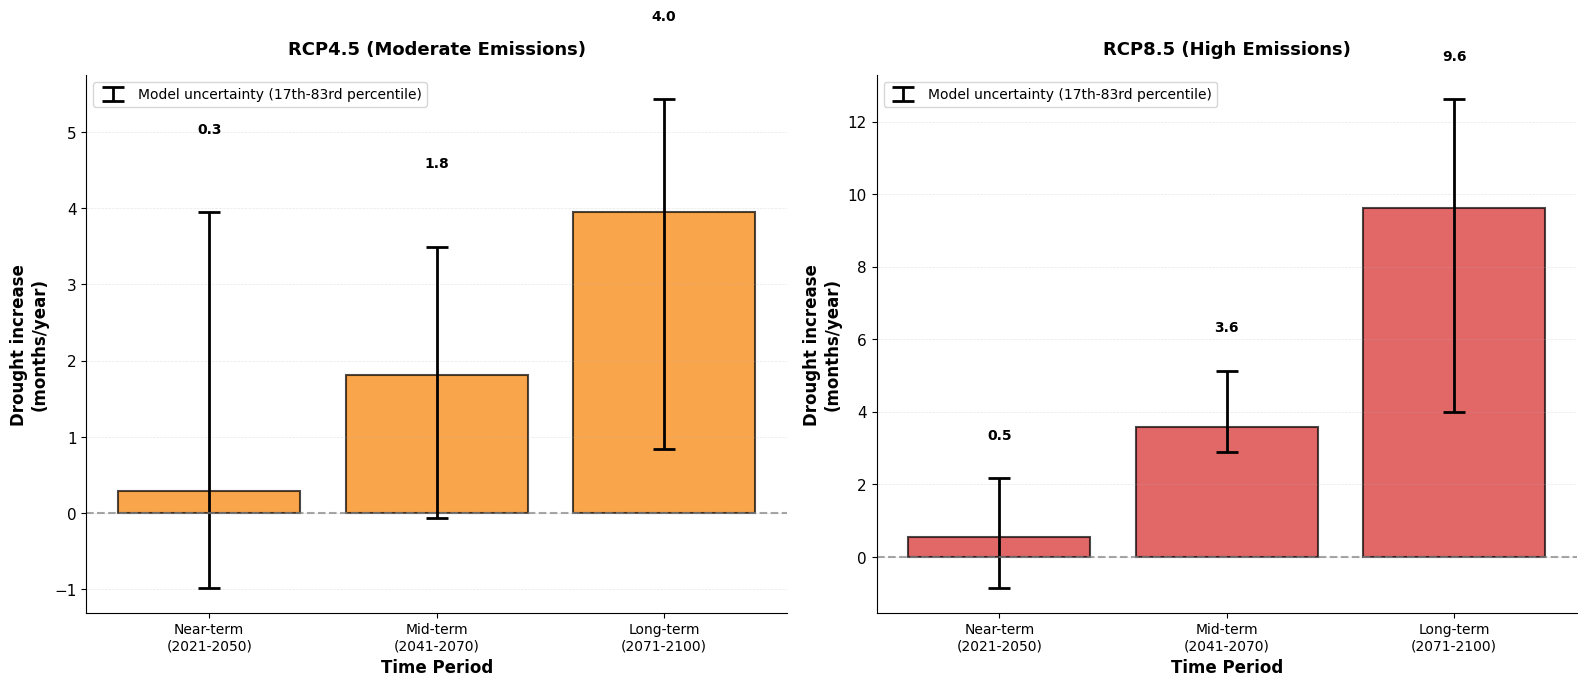


💡 Values show average increase in drought months per year,
   relative to baseline period 1991-2020


In [84]:
# Visualize drought increase by period with model uncertainty
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

scenarios = ['RCP4_5', 'RCP8_5']
scenario_names = {'RCP4_5': 'RCP4.5 (Moderate Emissions)', 'RCP8_5': 'RCP8.5 (High Emissions)'}
scenario_colors = {'RCP4_5': '#F77F00', 'RCP8_5': '#D62828'}
period_order = ['Near-term', 'Mid-term', 'Long-term']

for idx, scenario in enumerate(scenarios):
    ax = axes[idx]
    
    # Use the first threshold for the main visualization
    threshold = thresholds[0]
    data = threshold_results[threshold]
    scenario_data = data[data['scenario'] == scenario]
    
    # Prepare data for plotting
    x_pos = np.arange(len(period_order))
    medians = []
    errors_lower = []
    errors_upper = []
    
    for period in period_order:
        period_data = scenario_data[scenario_data['period'] == period]
        if len(period_data) > 0:
            median = period_data['drought_increase_median'].values[0]
            p17 = period_data['drought_increase_p17'].values[0]
            p83 = period_data['drought_increase_p83'].values[0]
            
            # Convert to per-year values for clarity
            medians.append(median / period_length)
            errors_lower.append((median - p17) / period_length)
            errors_upper.append((p83 - median) / period_length)
        else:
            medians.append(0)
            errors_lower.append(0)
            errors_upper.append(0)
    
    # Create bar chart
    bars = ax.bar(x_pos, medians, 
                   color=scenario_colors[scenario], alpha=0.7, 
                   edgecolor='black', linewidth=1.5)
    
    # Add error bars
    ax.errorbar(x_pos, medians, 
                yerr=[errors_lower, errors_upper],
                fmt='none', ecolor='black', capsize=8, capthick=2, linewidth=2,
                label='Model uncertainty (17th-83rd percentile)')
    
    # Add horizontal line at zero
    ax.axhline(0, color='gray', linestyle='--', linewidth=1.5, alpha=0.7)
    
    # Customize plot
    ax.set_xlabel('Time Period', fontsize=12, fontweight='bold')
    ax.set_ylabel('Drought increase\n(months/year)', fontsize=12, fontweight='bold')
    ax.set_title(scenario_names[scenario], fontsize=13, fontweight='bold', pad=15)
    ax.set_xticks(x_pos)
    ax.set_xticklabels([f'{p}\n({periods[p][0]}-{periods[p][1]})' for p in period_order], fontsize=10)
    ax.legend(loc='upper left', fontsize=10, frameon=True)
    ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.5, axis='y')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    # Add value labels on bars
    for i, (bar, val) in enumerate(zip(bars, medians)):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + errors_upper[i] + 1,
                f'{val:.1f}', ha='center', va='bottom', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.show()

print(f"\n💡 Values show average increase in drought months per year,")
print(f"   relative to baseline period {periods['Baseline'][0]}-{periods['Baseline'][1]}")

In [85]:
# Population exposure when drought increases exceed thresholds
print("="*90)
print(f"POPULATION EXPOSURE TO DROUGHT INCREASES")
print(f"(Baseline: {periods['Baseline'][0]}-{periods['Baseline'][1]})")
print("="*90)

for scenario in scenarios:
    print(f"\n{scenario_names[scenario].upper()}")
    print("-"*90)
    
    for period in period_order:
        print(f"\n  {period} ({periods[period][0]}-{periods[period][1]}):")
        
        for threshold in thresholds:
            data = threshold_results[threshold]
            period_data = data[(data['scenario'] == scenario) & (data['period'] == period)]
            
            if len(period_data) > 0:
                pop = period_data['population'].values[0]
                n_exceed = period_data['n_models_exceed'].values[0]
                n_total = period_data['n_models_total'].values[0]
                pct_models = (n_exceed / n_total) * 100
                drought_increase = period_data['drought_increase_median'].values[0]
                
                # Estimate population at risk based on model agreement
                if pct_models > 66:  # Strong agreement (>2/3 models)
                    risk_level = "HIGH"
                    pop_at_risk = pop
                elif pct_models > 33:  # Moderate agreement
                    risk_level = "MODERATE"
                    pop_at_risk = pop * 0.5
                else:  # Weak agreement
                    risk_level = "LOW"
                    pop_at_risk = 0
                
                print(f"    Drought increase ≥ +{threshold} months:")
                print(f"      Model agreement: {n_exceed}/{n_total} models ({pct_models:.0f}%) → Risk: {risk_level}")
                print(f"      Population at risk: {pop_at_risk/1e6:.2f} million ({(pop_at_risk/pop)*100:.0f}% of {pop/1e6:.2f}M)")
                print(f"      Drought increase: {drought_increase:+.1f} months total ({drought_increase/period_length:+.2f} months/year)")

print("\n" + "="*90)
print("\n💡 Interpretation:")
print(f"   - Drought increases show CUMULATIVE additional months over {period_length} years,")
print(f"     relative to {periods['Baseline'][0]}-{periods['Baseline'][1]} baseline")
print(f"   - Example: '+60 months total' = +2.0 months/year average increase")
print(f"   - Population at risk depends on model agreement:")
print(f"     • HIGH (>66% models): All population exposed")
print(f"     • MODERATE (33-66% models): ~50% population exposed")
print(f"     • LOW (<33% models): Minimal exposure")

POPULATION EXPOSURE TO DROUGHT INCREASES
(Baseline: 1991-2020)

RCP4.5 (MODERATE EMISSIONS)
------------------------------------------------------------------------------------------

  Near-term (2021-2050):
    Drought increase ≥ +10 months:
      Model agreement: 4/9 models (44%) → Risk: MODERATE
      Population at risk: 0.20 million (50% of 0.40M)
      Drought increase: +8.6 months total (+0.29 months/year)
    Drought increase ≥ +15 months:
      Model agreement: 4/9 models (44%) → Risk: MODERATE
      Population at risk: 0.20 million (50% of 0.40M)
      Drought increase: +8.6 months total (+0.29 months/year)
    Drought increase ≥ +20 months:
      Model agreement: 4/9 models (44%) → Risk: MODERATE
      Population at risk: 0.20 million (50% of 0.40M)
      Drought increase: +8.6 months total (+0.29 months/year)

  Mid-term (2041-2070):
    Drought increase ≥ +10 months:
      Model agreement: 6/9 models (67%) → Risk: HIGH
      Population at risk: 0.32 million (100% of 0.32M)

## Summary

This tutorial demonstrated how to combine drought hazard and population data to estimate drought exposure:

**Historical trends (1975-2020):**
- Historical drought exposure reflects both drought variability and population changes
- ERA5 reanalysis provides observed drought patterns  
- GHS-WUP provides consistent population estimates
- Population gaps filled using persistence (forward fill) for complete timeseries

**Future projections (2021-2100):**
- Climate change is projected to increase drought duration
- Population changes also affect total exposure
- RCP8.5 shows higher exposure than RCP4.5 by end-of-century
- Multi-model ensembles quantify projection uncertainty

**Threshold-based analysis (30-year periods):**
- Identifies population exposed to significant drought increases relative to 1991-2020 baseline
- Uses **cumulative drought months** per 30-year period for clearer long-term trends
- Provides actionable estimates with model uncertainty quantified via error bars
- Accounts for model agreement in assessing exposure risk

**Key results for Central Greece (EL64):**
- **Baseline (1991-2020)**: ~2.2 months of drought per year
- **RCP4.5 long-term (2071-2100)**: ~4.0-4.5 months/year → increase of ~2 months/year
- **RCP8.5 long-term (2071-2100)**: ~4.5-5.0 months/year → increase of ~2.5 months/year
- Under RCP8.5, nearly all models (9/9) show significant drought increases by end-of-century
- By 2071-2100, entire population (~0.22M) faces increased drought exposure under RCP8.5

**Key takeaways:**
- Exposure = Hazard × Population (both components matter)
- Multiple climate models are essential for assessing uncertainty
- Different emission scenarios lead to different exposure outcomes
- 30-year cumulative analysis reveals long-term trends more clearly than annual values
- Model agreement provides confidence levels for risk assessment
- Early climate action (RCP4.5) can substantially reduce future drought exposure

```{admonition} Next Steps
:class: tip
To complete a full drought **risk** assessment, you would also need to incorporate:
- **Vulnerability**: Socioeconomic factors that affect drought impacts
- **Adaptation**: Measures to reduce exposure or vulnerability
```